### This notebook loads the summary of Heart Rate from subjects of Social dataset and looks into systematic differences across tasks

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf

In [6]:
# load HR summary tsv
tsv_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/physio/HR_summary.tsv'
hr_df = pd.read_csv(tsv_path, sep='\t')
hr_df.head()

,subj_id,run_num,task_name,task_code,avg_instruction_HR,avg_task_HR
0,sub-05,1,action_prediction,action_prediction,57.104500,56.659217
1,sub-05,1,frith_happe,frith_happe,57.615986,57.468941
2,sub-05,1,theory_of_mind,tom,59.004135,58.739100
3,sub-05,1,strange_stories,strange_stories,59.347420,58.251872
4,sub-05,1,liking,liking,58.661684,59.130879


In [7]:
# Make sure task_name is categorical
hr_df['task_name'] = hr_df['task_name'].astype('category')

# Reorder categories so 'rest' is first (the reference)
categories = ['rest'] + [t for t in hr_df['task_name'].cat.categories if t != 'rest']
hr_df['task_name'] = hr_df['task_name'].cat.reorder_categories(categories, ordered=True)

# Average across all subjects & runs
task_means = hr_df.groupby("task_name")[["avg_instruction_HR", "avg_task_HR"]].mean()
print(task_means)

                   avg_instruction_HR  avg_task_HR
task_name                                         
rest                        65.150072    63.642846
action_prediction           65.703108    64.907773
demand_grid                 65.395849    65.911900
faux_pas                    65.492514    65.150730
frith_happe                 65.610436    63.851132
liking                      65.717926    64.808464
picture_sequence            65.751854    64.527716
rmet                        65.759097    64.846291
strange_stories             65.751415    64.085074
theory_of_mind              65.732970    64.948293


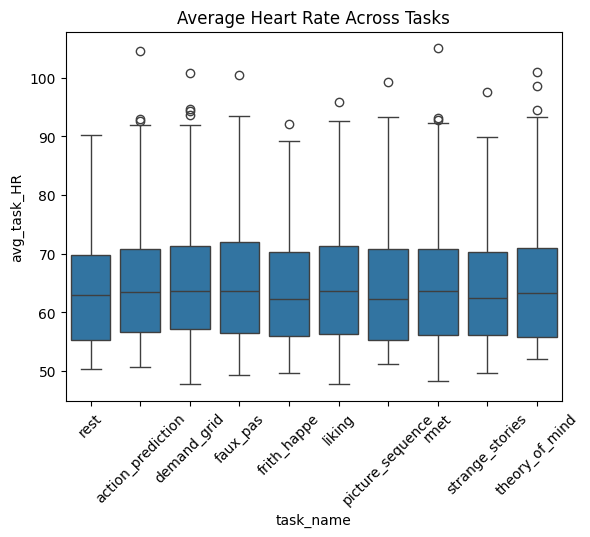

In [8]:
sns.boxplot(x="task_name", y="avg_task_HR", data=hr_df)
plt.title("Average Heart Rate Across Tasks")
plt.xticks(rotation=45)
plt.show()

In [14]:
# Group data into lists, one per task
task_groups = [group["avg_task_HR"].values for _, group in hr_df.groupby("task_name")]

# One-way ANOVA
f_val, p_val = stats.f_oneway(*task_groups)
print(f"ANOVA: F={f_val:.3f}, p={p_val:.3e}")

ANOVA: F=0.794, p=6.219e-01


In [13]:
# Average HR across runs per subject per task
subject_task_avg = hr_df.groupby(['subj_id','task_name'])['avg_task_HR'].mean().reset_index()

# Prepare for one-way ANOVA: one array per task
task_groups = [g['avg_task_HR'].values for _, g in subject_task_avg.groupby('task_name')]

# One-way ANOVA
f_val, p_val = stats.f_oneway(*task_groups)
print(f"ANOVA on per-subject averages: F={f_val:.3f}, p={p_val:.3f}")

ANOVA on per-subject averages: F=0.078, p=1.000
